In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Fashion_Market_Research_250_Real_Sourcedata.xlsx")

# Sirf actual 242 product records
df = df.iloc[:242].copy()

print(df.shape)
df.head()

(242, 11)


,,Brand,Product_Name,Category,Sub_Category,Gender,Selling_Price_INR,Original_Price_INR,Price_Segment,Data_Collected_Date,Source_URL
0,1.0,Nike,Nike Shox TL Men's Shoes,Footwear,Lifestyle,Men,15995,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
1,2.0,Nike,Nike Zoom Vomero 5 Men's Shoes,Footwear,Lifestyle,Men,14995,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
2,3.0,Nike,Nike Air Max 95 Older Bubble Men's Shoes,Footwear,Lifestyle,Men,16995,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
3,4.0,Nike,Nike Ava X Mesh Men's Shoes,Footwear,Lifestyle,Men,10795,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
4,5.0,Nike,Nike Air Max Dn8 Men's Shoes,Footwear,Lifestyle,Men,17495,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/


In [10]:
brand_analysis = df.groupby("Brand").agg(
    Products=("Record_ID", "count"),
    Avg_Price=("Selling_Price_INR", "mean"),
    Median_Price=("Selling_Price_INR", "median")
).round(2)

brand_analysis

,Products,Avg_Price,Median_Price
Brand,,,
H&M,46,1226.2,1199.0
Nike,50,10483.666667,11395.0
UNIQLO,49,2032.857143,1990.0
Zara,50,4310.416667,4150.0
adidas,47,7325.0,6599.0


In [4]:
print(df.columns.tolist())


[' ', 'Brand', 'Product_Name', 'Category', 'Sub_Category', 'Gender', 'Selling_Price_INR', 'Original_Price_INR', 'Price_Segment', 'Data_Collected_Date', 'Source_URL']


In [8]:
df = df.rename(columns={' ': 'Record_ID'})

In [9]:
print(df.columns.tolist())

['Record_ID', 'Brand', 'Product_Name', 'Category', 'Sub_Category', 'Gender', 'Selling_Price_INR', 'Original_Price_INR', 'Price_Segment', 'Data_Collected_Date', 'Source_URL']


In [11]:
category_analysis = (
    df["Category"]
    .value_counts()
    .reset_index()
)

category_analysis.columns = ["Category", "Products"]

print(category_analysis)

      Category  Products
0      Apparel       147
1     Footwear        82
2    Innerwear         8
3  Accessories         2
4   Sportswear         1
5         Home         1
6       Beauty         1


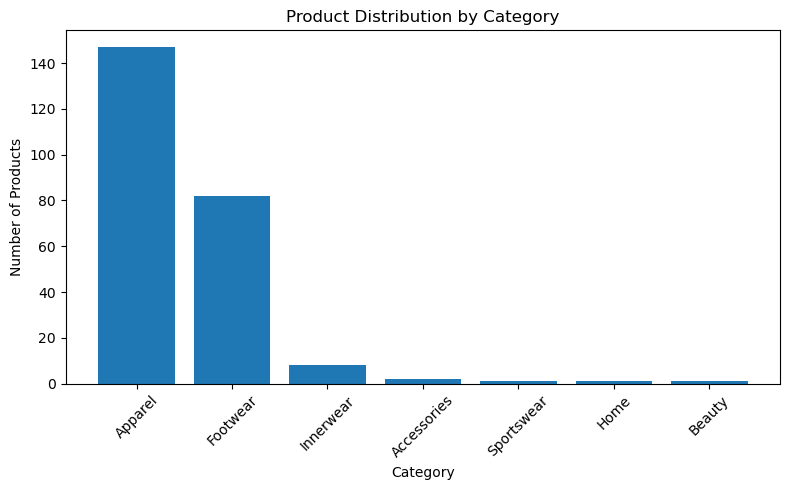

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Products"]
)

plt.title("Product Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
price_segment = df["Price_Segment"].value_counts()

print(price_segment)

Price_Segment
Budget            66
Mid-range         62
Premium           32
Luxury/Premium    29
Name: count, dtype: int64


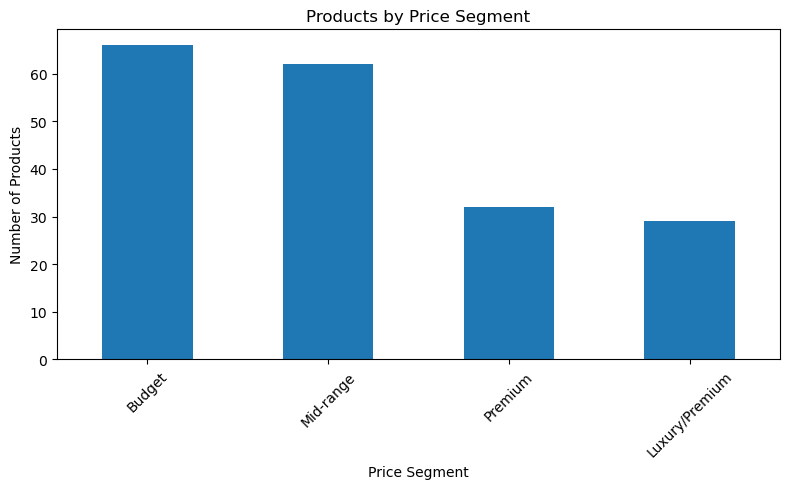

In [14]:
plt.figure(figsize=(8,5))

price_segment.plot(kind="bar")

plt.title("Products by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
gender_analysis = df["Gender"].value_counts()

print(gender_analysis)

Gender
Women          153
Men             49
Unspecified     34
Kids             3
Unisex           3
Name: count, dtype: int64


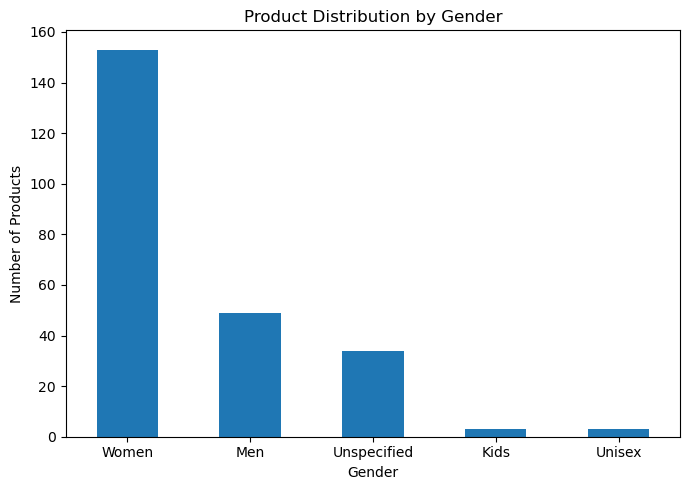

In [16]:
plt.figure(figsize=(7,5))

gender_analysis.plot(kind="bar")

plt.title("Product Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
category_price = df.groupby("Category")["Selling_Price_INR"].agg(
    ["count", "mean", "median"]
).round(2)

print(category_price)

             count         mean   median
Category                                
Accessories      1        749.0    749.0
Apparel        124  2802.209677   2490.0
Beauty           0          NaN      NaN
Footwear        56      10767.0  10897.0
Home             0          NaN      NaN
Innerwear        7  1218.571429    790.0
Sportswear       1        899.0    899.0


C:\Users\patil hiral\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\patil hiral\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [18]:
brand_price = df.groupby("Brand")["Selling_Price_INR"].agg(
    ["count", "mean", "median"]
).round(2)

print(brand_price)

        count          mean   median
Brand                               
H&M        25        1226.2   1199.0
Nike       42  10483.666667  11395.0
UNIQLO     49   2032.857143   1990.0
Zara       48   4310.416667   4150.0
adidas     25        7325.0   6599.0


In [19]:
gender_price = df.groupby("Gender")["Selling_Price_INR"].agg(
    ["count", "mean", "median"]
).round(2)

print(gender_price)

             count          mean   median
Gender                                   
Kids             1       10999.0  10999.0
Men             38  10774.236842  11395.0
Unisex           3   1656.666667   1490.0
Unspecified     15        6255.4   6599.0
Women          132   3343.810606   2490.0


In [20]:
price_segment = df.groupby("Price_Segment")["Selling_Price_INR"].agg(
    ["count", "mean", "median"]
).round(2)

print(price_segment)

                count          mean   median
Price_Segment                               
Budget             66   1305.909091   1490.0
Luxury/Premium     29  14235.517241  14195.0
Mid-range          62   3538.758065   3950.0
Premium            32    7568.15625   7772.5


In [22]:
brand_count = df["Brand"].value_counts()
print(brand_count)

Brand
Nike      50
Zara      50
UNIQLO    49
adidas    47
H&M       46
Name: count, dtype: int64


In [23]:
category_count = df["Category"].value_counts()

print(category_count)

Category
Apparel        147
Footwear        82
Innerwear        8
Accessories      2
Sportswear       1
Home             1
Beauty           1
Name: count, dtype: int64


In [24]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
Women          153
Men             49
Unspecified     34
Kids             3
Unisex           3
Name: count, dtype: int64


In [25]:
segment_count = df["Price_Segment"].value_counts()

print(segment_count)

Price_Segment
Budget            66
Mid-range         62
Premium           32
Luxury/Premium    29
Name: count, dtype: int64


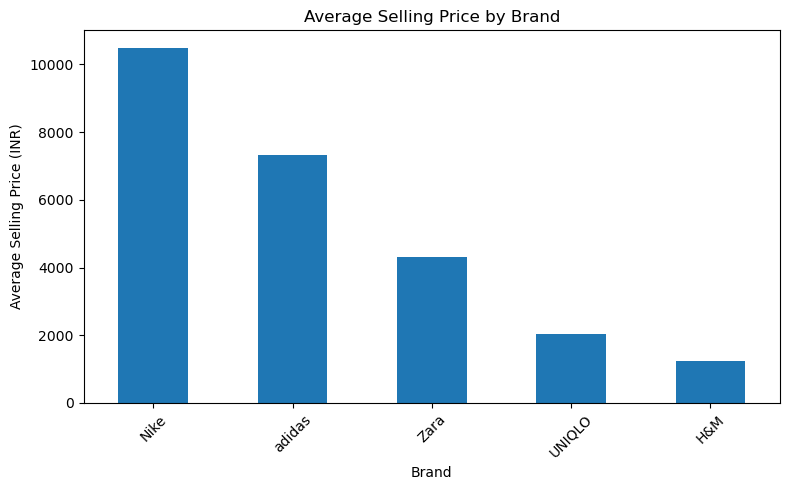

In [26]:
import matplotlib.pyplot as plt

brand_price["mean"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Selling Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Selling Price (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

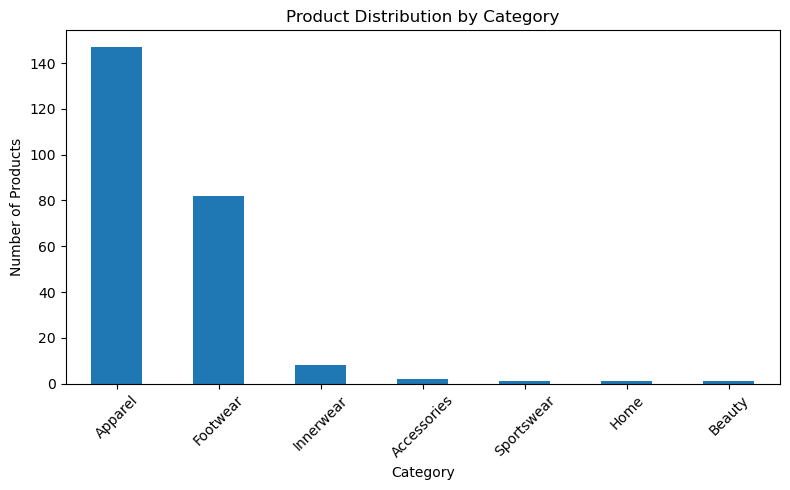

In [27]:
import matplotlib.pyplot as plt

category_count.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Product Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

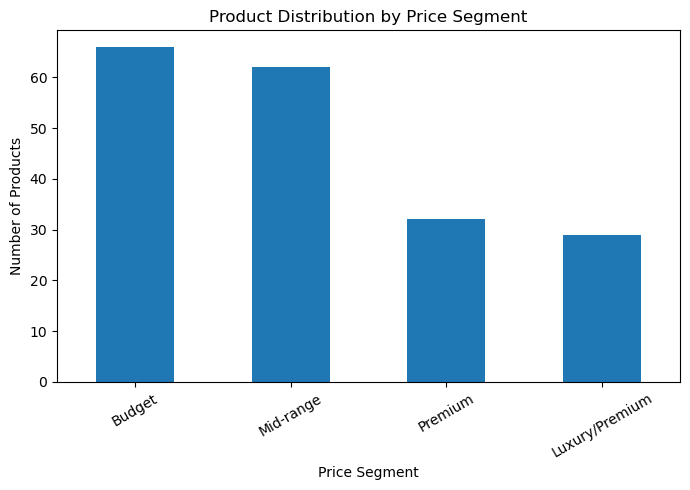

In [29]:
segment_count.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Product Distribution by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Products")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

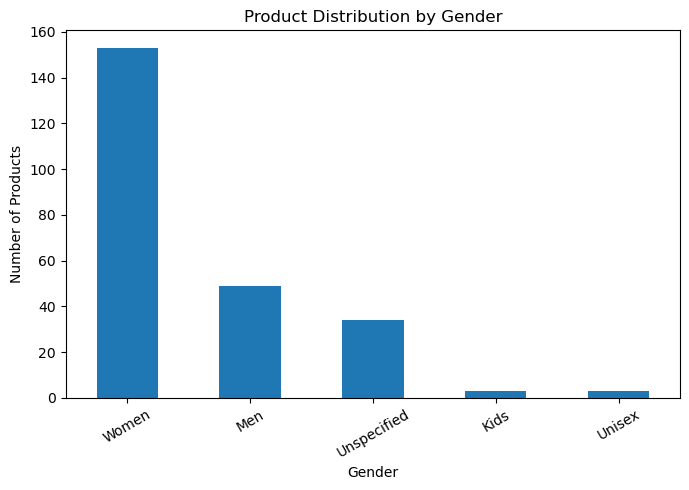

In [30]:
gender_count.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Product Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Products")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

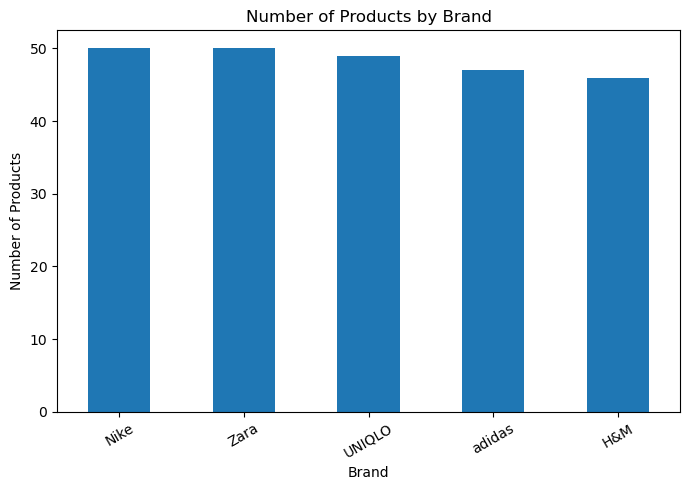

In [31]:
brand_count.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Number of Products by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

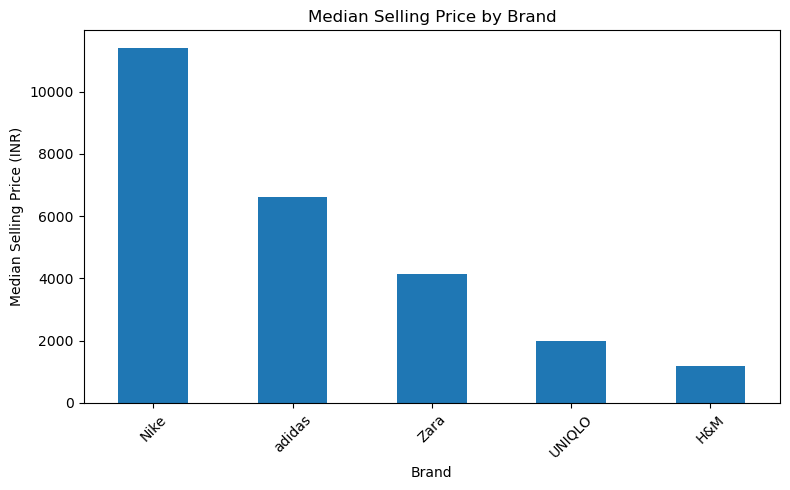

In [32]:
brand_price["median"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Median Selling Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Median Selling Price (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

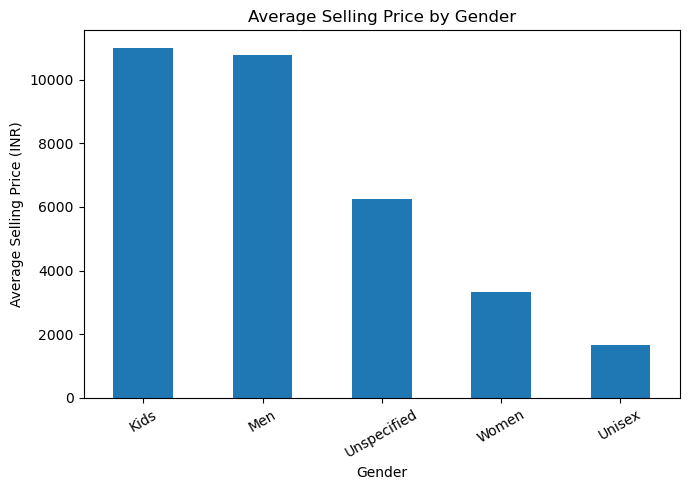

In [33]:
gender_price["mean"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Selling Price by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Selling Price (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

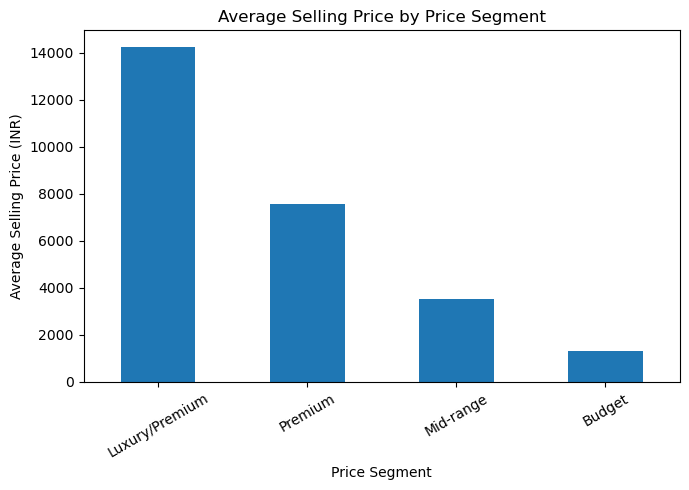

In [34]:
price_segment["mean"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Selling Price by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Average Selling Price (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()